In [1]:
import numpy as np
import matplotlib as plt
import pandas as pd
import seaborn as sns
import sklearn as skl

In [2]:
df=pd.read_csv('global_ev_adoption_behavior_2026.csv');
print(df.head());
print(df.isnull().sum());
print(df.isnull().sum().sum());

df['education_level']=df['education_level'].fillna(df['education_level'].mode()[0]);
df['charging_station_accessibility']=df['charging_station_accessibility'].fillna(df['charging_station_accessibility'].mean());
df['ev_knowledge_score']=df['ev_knowledge_score'].fillna(df['ev_knowledge_score'].median());


   age  annual_income education_level city_type  daily_commute_km  \
0   56        23019.0     High School  Suburban              39.8   
1   46        26440.0     High School  Suburban              34.6   
2   46        57167.0             PhD  Suburban              30.5   
3   23        15841.0          Master  Suburban              44.6   
4   50        51571.0          Master     Urban              52.4   

   weekly_travel_distance_km current_vehicle_type  vehicle_age_years  \
0                      205.7            Hatchback                6.1   
1                      218.4                Sedan                4.4   
2                      177.7                Sedan                0.4   
3                      325.9                  SUV                0.0   
4                      281.0                  SUV                5.2   

   fuel_expense_per_month  charging_station_accessibility  ...  \
0                   317.1                             3.9  ...   
1                   

In [3]:
print(df.isna().sum());
print(df.isna().sum().sum());
print(df.select_dtypes(include=np.number).corr());
print(df.describe());
print(df.duplicated().sum());

age                               0
annual_income                     0
education_level                   0
city_type                         0
daily_commute_km                  0
weekly_travel_distance_km         0
current_vehicle_type              1
vehicle_age_years                 1
fuel_expense_per_month            1
charging_station_accessibility    0
nearest_charging_station_km       1
home_charging_available           1
electricity_cost_per_kwh          1
environmental_awareness_score     1
government_incentive_awareness    1
technology_affinity_score         1
range_anxiety_score               1
battery_replacement_concern       1
ev_knowledge_score                0
previous_ev_experience            1
ev_adoption_likelihood            1
monthly_energy_consumption_kwh    1
monthly_charging_cost             1
dtype: int64
15
                                     age  annual_income  daily_commute_km  \
age                             1.000000      -0.003345         -0.006307   
an

In [5]:
print(df.isna().sum());
print(df.isna().sum().sum());
print(df.select_dtypes(include=np.number).corr());
print(df.describe());

age                               0
annual_income                     0
education_level                   0
city_type                         0
daily_commute_km                  0
weekly_travel_distance_km         0
current_vehicle_type              1
vehicle_age_years                 1
fuel_expense_per_month            1
charging_station_accessibility    0
nearest_charging_station_km       1
home_charging_available           1
electricity_cost_per_kwh          1
environmental_awareness_score     1
government_incentive_awareness    1
technology_affinity_score         1
range_anxiety_score               1
battery_replacement_concern       1
ev_knowledge_score                0
previous_ev_experience            1
ev_adoption_likelihood            1
monthly_energy_consumption_kwh    1
monthly_charging_cost             1
dtype: int64
15
                                     age  annual_income  daily_commute_km  \
age                             1.000000      -0.003345         -0.006307   
an

                       age  annual_income  daily_commute_km
age               1.000000      -0.003345         -0.006307
annual_income    -0.003345       1.000000          0.006975
daily_commute_km -0.006307       0.006975          1.000000


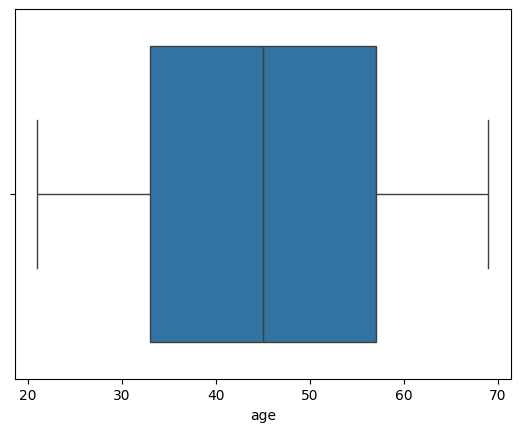

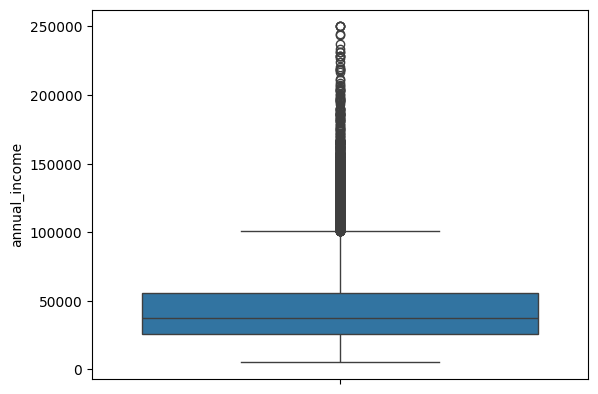

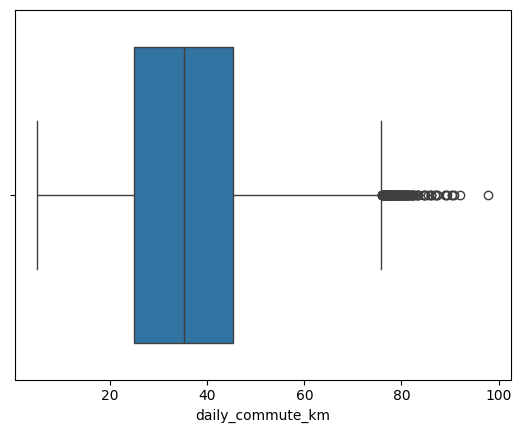

In [6]:
print(df[['age', 'annual_income', 'daily_commute_km']].corr())

sns.boxplot(df['age'], orient='h');
plt.pyplot.show();
sns.boxplot(df['annual_income'], orient='v');
plt.pyplot.show();
sns.boxplot(df['daily_commute_km'], orient='h');
plt.pyplot.show();

In [7]:
q1=df['age'].quantile(0.25);
q3=df['age'].quantile(0.75);
iqr=q3-q1;
lower_bound=q1-1.5*iqr;
upper_bound=q3+1.5*iqr;
print('the quantile(0.25) for age is:',q1,',the quantile for age (0.75) is:',q3,',the iqr is:',iqr,',lower_bound:',lower_bound,',upper bound:',upper_bound);
df=df[(df['age']>=lower_bound)&(df['age']<=upper_bound)];

the quantile(0.25) for age is: 33.0 ,the quantile for age (0.75) is: 57.0 ,the iqr is: 24.0 ,lower_bound: -3.0 ,upper bound: 93.0


In [8]:
q1=df['daily_commute_km'].quantile(0.25);
q3=df['daily_commute_km'].quantile(0.75);
iqr=q3-q1;
lower_bound=q1-1.5*iqr;
upper_bound=q3+1.5*iqr;
print('the quantile(0.25) for daily commute is:',q1,',the quantile for daily commute (0.75) is:',q3,',the iqr is:',iqr,',lower_bound:',lower_bound,',upper bound:',upper_bound);
df=df[(df['daily_commute_km']>=lower_bound)&(df['daily_commute_km']<=upper_bound)];

the quantile(0.25) for daily commute is: 24.8 ,the quantile for daily commute (0.75) is: 45.2 ,the iqr is: 20.400000000000002 ,lower_bound: -5.800000000000001 ,upper bound: 75.80000000000001


In [9]:
q1=df['annual_income'].quantile(0.25);
q3=df['annual_income'].quantile(0.75);
iqr=q3-q1;
lower_bound=q1-1.5*iqr;
upper_bound=q3+1.5*iqr;
print('the quantile(0.25) for annual_income is:',q1,',the quantile for annual_income (0.75) is:',q3,',the iqr is:',iqr,',lower_bound:',lower_bound,',upper bound:',upper_bound);
df=df[(df['annual_income']>=lower_bound)&(df['annual_income']<=upper_bound)];

the quantile(0.25) for annual_income is: 25567.0 ,the quantile for annual_income (0.75) is: 55722.0 ,the iqr is: 30155.0 ,lower_bound: -19665.5 ,upper bound: 100954.5


outliers for age,daily_commute and annual_income has been removed and the dataset has been updated accordingly.

In [10]:
print(df.head(1))

   age  annual_income education_level city_type  daily_commute_km  \
0   56        23019.0     High School  Suburban              39.8   

   weekly_travel_distance_km current_vehicle_type  vehicle_age_years  \
0                      205.7            Hatchback                6.1   

   fuel_expense_per_month  charging_station_accessibility  ...  \
0                   317.1                             3.9  ...   

   environmental_awareness_score  government_incentive_awareness  \
0                            8.3                             6.4   

   technology_affinity_score  range_anxiety_score  \
0                        5.2                  4.6   

   battery_replacement_concern  ev_knowledge_score  previous_ev_experience  \
0                          3.5                 6.9                     0.0   

   ev_adoption_likelihood  monthly_energy_consumption_kwh  \
0                    High                           199.8   

   monthly_charging_cost  
0                   28.5  

[1 r

In [11]:
likelihood_mapping = {'Low': 0, 'Medium': 1, 'High': 2};
df['ev_adoption_likelihood_numeric'] = df['ev_adoption_likelihood'].map(likelihood_mapping);
print(df[['age','annual_income','fuel_expense_per_month','daily_commute_km','ev_adoption_likelihood_numeric']].corr());

                                     age  annual_income  \
age                             1.000000       0.004164   
annual_income                   0.004164       1.000000   
fuel_expense_per_month         -0.006329       0.006819   
daily_commute_km               -0.006231       0.007945   
ev_adoption_likelihood_numeric  0.007898       0.377849   

                                fuel_expense_per_month  daily_commute_km  \
age                                          -0.006329         -0.006231   
annual_income                                 0.006819          0.007945   
fuel_expense_per_month                        1.000000          0.950262   
daily_commute_km                              0.950262          1.000000   
ev_adoption_likelihood_numeric                0.006585          0.008222   

                                ev_adoption_likelihood_numeric  
age                                                   0.007898  
annual_income                                         0.37

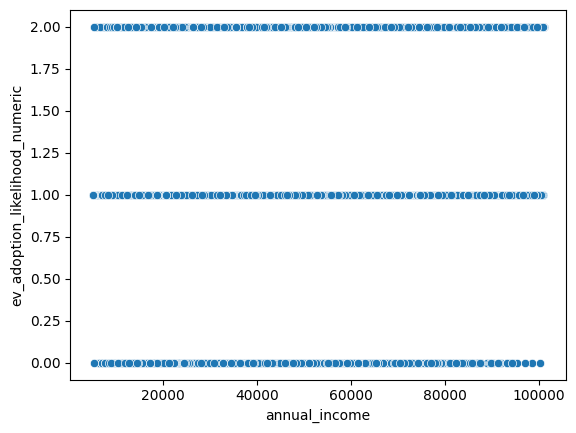

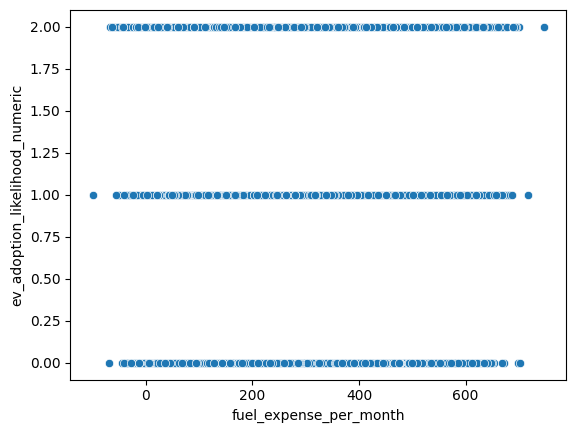

In [12]:
sns.scatterplot(data=df,x='annual_income',y='ev_adoption_likelihood_numeric');
plt.pyplot.show();
sns.scatterplot(data=df,x='fuel_expense_per_month',y='ev_adoption_likelihood_numeric');
plt.pyplot.show();

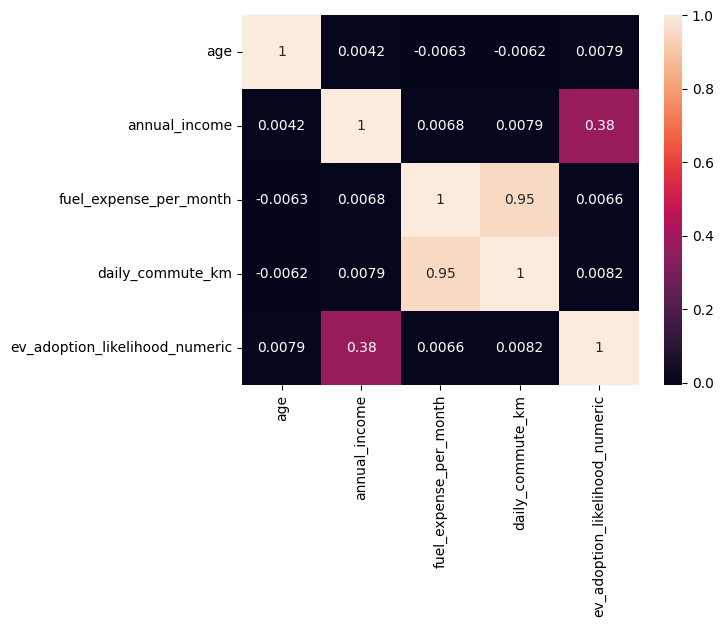

In [13]:
corr = df[['age','annual_income','fuel_expense_per_month','daily_commute_km','ev_adoption_likelihood_numeric']].corr();
sns.heatmap(corr,annot=True);
plt.pyplot.show();

In [14]:
from scipy.stats import pearsonr
pearsonr(
    df['annual_income'],
    df['ev_adoption_likelihood_numeric']
)

PearsonRResult(statistic=np.float64(nan), pvalue=np.float64(nan))

my summary would be that the likelihood that one will most likely switch to an ev is based on ones own anuual income as it can be seen from the above given heatmap as well and it can also be seen from the pearson coefficient value as well.


In [15]:
from sklearn.feature_selection import VarianceThreshold

df_numeric = df.select_dtypes(include=np.number);
selector = VarianceThreshold(threshold=0.0);
selected_features = selector.fit_transform(df_numeric);
print(f"Original number of numerical features: {df_numeric.shape[1]}");
print(f"Number of features after VarianceThreshold: {selected_features.shape[1]}");
sel1=VarianceThreshold(0.01);
sel1.fit_transform(df_numeric);
print(f"Number of features after VarianceThreshold(0.01): {sel1.transform(df_numeric).shape[1]}");


Original number of numerical features: 20
Number of features after VarianceThreshold: 20
Number of features after VarianceThreshold(0.01): 19


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

features = ['age','daily_commute_km','annual_income']
target = 'ev_adoption_likelihood_numeric'
df_model = df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42);
model = LinearRegression();
model.fit(X_train,y_train);
y_pred=model.predict(X_test);
mse=mean_squared_error(y_test,y_pred);
r2=r2_score(y_test,y_pred);
print('mean squared error:',mse);
print('r2 score:',r2);

mean squared error: 0.4976251829584209
r2 score: 0.14243268957999566


To potentially improve the R2 score, let's analyze the correlation of all numerical features with ev_adoption_likelihood_numeric to select more predictive features.

In [17]:
import numpy as np
correlation_with_target = df.select_dtypes(include=np.number).corrwith(df['ev_adoption_likelihood_numeric']).sort_values(ascending=False)

print("Correlation of numerical features with 'ev_adoption_likelihood_numeric':\n")
print(correlation_with_target)
top_features = correlation_with_target[1:6].index.tolist()

print(f"\nTop 5 features with highest correlation to 'ev_adoption_likelihood_numeric': {top_features}")

Correlation of numerical features with 'ev_adoption_likelihood_numeric':

ev_adoption_likelihood_numeric    1.000000
ev_knowledge_score                0.721659
environmental_awareness_score     0.688632
technology_affinity_score         0.678816
annual_income                     0.377849
charging_station_accessibility    0.178917
government_incentive_awareness    0.123283
home_charging_available           0.100042
previous_ev_experience            0.086181
weekly_travel_distance_km         0.008870
daily_commute_km                  0.008222
age                               0.007898
monthly_energy_consumption_kwh    0.007359
monthly_charging_cost             0.007010
fuel_expense_per_month            0.006585
electricity_cost_per_kwh         -0.002098
vehicle_age_years                -0.007555
nearest_charging_station_km      -0.106030
battery_replacement_concern      -0.154277
range_anxiety_score              -0.697604
dtype: float64

Top 5 features with highest correlation to 'ev_ado

Based on the correlations, annual_income, technology_affinity_score, government_incentive_awareness, ev_knowledge_score, and environmental_awareness_score seem to be strong predictors. Let's include these in our model and retrain it.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,precision_score,recall_score,f1_score
selected_columns = top_features + ['ev_adoption_likelihood_numeric']
df_cleaned = df[selected_columns].dropna()

X_new = df_cleaned[top_features]
y_new = df_cleaned['ev_adoption_likelihood_numeric']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

model_new = LogisticRegression(max_iter=1000)
model_new.fit(X_train_new, y_train_new)

y_pred_new = model_new.predict(X_test_new)
confusion=confusion_matrix(y_test_new,y_pred_new);
print('confusion matrix:\n',confusion);
accuracy=accuracy_score(y_test_new,y_pred_new);
print('accuracy score:',accuracy);
recall=recall_score(y_test_new,y_pred_new,average='weighted');
print('recall score:',recall);
precision=precision_score(y_test_new,y_pred_new,average='weighted');
print('precision score:',precision);
f1=f1_score(y_test_new,y_pred_new,average='weighted');
print('f1 score:',f1);

confusion matrix:
 [[ 557  625   31]
 [ 266  896  594]
 [  39  252 3944]]
accuracy score: 0.7491671293725708
recall score: 0.7491671293725708
precision score: 0.7394369114906088
f1 score: 0.7408771915646011


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


now from this newer r2 score and mse value we can understand that the previous regression model had too little features and the score implies that this is much better and will give much better results as compared to the previous model.

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,precision_score,recall_score,f1_score
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_new)
X_test_scaled = scaler.transform(X_test_new)

model_scaled = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='auto')
model_scaled.fit(X_train_scaled, y_train_new)

y_pred_scaled = model_scaled.predict(X_test_scaled)
confusion_scaled = confusion_matrix(y_test_new, y_pred_scaled)
accuracy_scaled = accuracy_score(y_test_new, y_pred_scaled)
recall_scaled = recall_score(y_test_new, y_pred_scaled, average='weighted')
precision_scaled = precision_score(y_test_new, y_pred_scaled, average='weighted')
f1_scaled = f1_score(y_test_new, y_pred_scaled, average='weighted')

print('Confusion Matrix (Scaled Data):\n', confusion_scaled)
print('Accuracy Score (Scaled Data):', accuracy_scaled)
print('Recall Score (Scaled Data):', recall_scaled)
print('Precision Score (Scaled Data):', precision_scaled)
print('F1 Score (Scaled Data):', f1_scaled)

print('\nClassification Report (Scaled Data):\n', classification_report(y_test_new, y_pred_scaled))

Confusion Matrix (Scaled Data):
 [[ 806  389   18]
 [ 276 1002  478]
 [  12  353 3870]]
Accuracy Score (Scaled Data): 0.7881732370905052
Recall Score (Scaled Data): 0.7881732370905052
Precision Score (Scaled Data): 0.7851817779049608
F1 Score (Scaled Data): 0.7862392404665094

Classification Report (Scaled Data):
               precision    recall  f1-score   support

         0.0       0.74      0.66      0.70      1213
         1.0       0.57      0.57      0.57      1756
         2.0       0.89      0.91      0.90      4235

    accuracy                           0.79      7204
   macro avg       0.73      0.72      0.72      7204
weighted avg       0.79      0.79      0.79      7204



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


so the conclusion which we have come up with is that it is always better to do some scaling before training your model. as we can see that the previous model trained had an accuracy,precision,recall and f1 score all at around 74% but after scaling the model gave accuracy,precision,recall and f1 score at around 78.8%.
so the improvement of model is pretty evident.